In [ ]:
!pip install torchmetrics
!pip install sentence-transformers

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from transformers import BertTokenizer, get_scheduler
from torch.utils.data import DataLoader, Dataset
import torch
from torchmetrics import Accuracy
from torch import nn, softmax
import torch.nn.functional as F
from torch.optim import AdamW
from transformers import BertForSequenceClassification
from tqdm.auto import tqdm
import itertools
from torch.nn import CrossEntropyLoss
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 961.5/961.5 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 26.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 18.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.2 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalli

## Importing the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222/data/df_feature_engineering.parquet'
df_feature_engineered = pd.read_parquet(file_path)
df_feature_engineered.head()

Mounted at /content/drive


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


In [ ]:
# Doing Label Encoding here so that each label is represented by a number

label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
label_2_index = {label: idx for idx, label in enumerate (label_order)}
index_2_label = {idx: label for label, idx in label_2_index.items()}
df_feature_engineered['label_encoded'] = df_feature_engineered['label'].map(label_2_index)
df_feature_engineered[['label', 'label_encoded']]

# Dropping the ".json" from the id and converting to integer
df_feature_engineered['id'] = df_feature_engineered['id'].str.replace('.json', '', regex=False).astype(int)

# Train, test, validation split
x = df_feature_engineered['statement']
y = df_feature_engineered['label_encoded'].values
ids = df_feature_engineered['id'].values

x_train, x_test, y_train, y_test, ids_train, ids_test = train_test_split(x, y, ids, test_size=0.2, random_state=42)

x_train, x_val, y_train, y_val, ids_train, ids_val = train_test_split(x_train, y_train, ids_train, test_size=0.2, random_state=42)

## Checking the length of statements to set max length

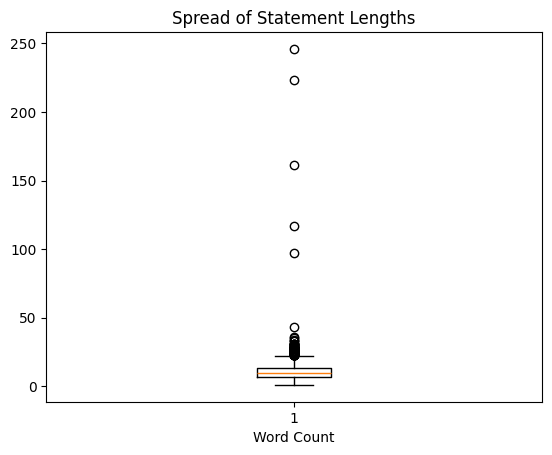

In [ ]:
word_count = df_feature_engineered['statement'].apply(lambda x: len(x.split()))
plt.boxplot(word_count)
plt.title('Spread of Statement Lengths')
plt.xlabel('Word Count')
plt.show()

From the boxplot, we see that the lengths of the statements are mostly less than 20 words long. The longest statement is about 250 words long. We can use this information to set the number of tokens for our BERT model.

## Initialising the model

Defining a custom PyTorch Dataset class to handle text data tokenised using BERT. This way, we will be able to prepare and serve batches of tokenized text, their labels , and IDs in a format suitable for training the BERT-based model.

In [ ]:
class BERTDataset(Dataset):
    def __init__(self, texts, labels, ids, tokenizer, max_length=20):
        self.texts = texts.values
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length
        self.ids = ids

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'labels': torch.tensor(self.labels[idx], dtype=torch.long),
            'ids': torch.tensor(self.ids[idx], dtype=torch.long)
        }

We set the max length of tokenized sequences to be 20, which includes special tokens like the separator token. Then, the pre-trained BERT tokenizer is loaded and we create datasets accordingly. The batch size is set to 16, so each batch in training, validation, and testing will contain 16 samples.

In [ ]:
max_length = 20
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')

train_dataset = BERTDataset(x_train, y_train, ids_train, tokenizer, max_length)
val_dataset = BERTDataset(x_val, y_val, ids_val, tokenizer, max_length)
test_dataset = BERTDataset(x_test, y_test, ids_test, tokenizer, max_length)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

BertForSequenceClassification is a pre-built BERT model head for classification. There are a total of 6 labels, and we train the model for 5 epochs over the entire training dataset.

In [ ]:
def initialize_model():
    return BertForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=6
    ).to(device)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = initialize_model()
model.to(device)
epochs = 5

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


The maximum token length is 20, and batch size is 16, as set previously. The input for the model would be a tensor with shape (16,20). The attention mask, which indicates which tokens are padding, will also have a shape of (16,20).

`bert-based-uncased` is a 12-layer transformer, each with a hidden size of 768. There are 12 self-attention heads, so each head works with a 64-dimensional subspace during attention. The output would be the last hidden state (16, 20, 768) and the pooled output (16,768).

There is an additional classification head, which takes the [CLS] token and passes it through a dropout layer and a linear layer. The outputs would be logits of shape (16, 6).

## Training function and evaluation function

For the training function, an optimiser with weight decay is initialised, where `num_warmup_steps_frac` refers to the fraction of total steps for which the learning rate will linearly increase before decaying. Since the labels are provided, BERT computes classification loss using the CrossEntropyLoss function.

In [ ]:
def bert_train(model, train_loader, params, epochs):
    learning_rate = params['learning_rate']
    num_warmup_steps_frac = params['num_warmup_steps']
    optimizer = AdamW(model.parameters(), lr=learning_rate)
    num_training_steps = len(train_loader) * epochs
    num_warmup_steps = int(num_warmup_steps_frac * num_training_steps)

    lr_scheduler = get_scheduler(
        name="linear",
        optimizer=optimizer,
        num_warmup_steps=num_warmup_steps,
        num_training_steps=num_training_steps
    )

    for epoch in range(epochs):
        print(f"\nStarting epoch {epoch + 1}")
        total_train_loss = 0
        model.train()

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(
                input_ids=batch['input_ids'],
                attention_mask=batch['attention_mask'],
                labels=batch['labels']
            )
            loss = outputs.loss
            total_train_loss += loss.item()

            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()

        avg_train_loss = total_train_loss / len(train_loader)
        print(f"Epoch {epoch + 1}, Training Loss: {avg_train_loss:.4f}")

The TorchMetrics' Accuracy class for multiclass classification is used, since we have 6 possible labels. The inputs are passed through the model and logits are extracted, and we get the predicted class by taking the index of the maximum logit for each statement.

In [ ]:
def bert_valid(model, val_loader, params, loss_fct):
    metric = Accuracy(task="multiclass", num_classes=6).to(device)
    model.eval()
    total_val_loss = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch_idx, batch in enumerate(val_loader):
            batch = {k: v.to(device) for k, v in batch.items()}
            input_ids = batch['input_ids']
            attention_mask = batch['attention_mask']
            labels = batch['labels']  # No need for torch.argmax()

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())  # Move to CPU for sklearn
            all_labels.extend(labels.cpu().numpy())

            loss = loss_fct(logits, labels)
            total_val_loss += loss.item()

            metric.update(preds.to(device), labels.to(device))

    avg_val_loss = total_val_loss / len(val_loader)
    accuracy = metric.compute()
    metric.reset()

    print(f"Loss: {avg_val_loss:.4f}")
    print(f"Accuracy: {accuracy:.4f}")
    return accuracy.item(), all_preds, all_labels

## Initial training and evaluation of the model

In [ ]:
# initial model
params = {
    'learning_rate': 1e-5,
    'num_warmup_steps': 0.1
}

bert_train(model, train_loader, params, epochs)


Starting epoch 1
Epoch 1, Training Loss: 1.7589

Starting epoch 2
Epoch 2, Training Loss: 1.6986

Starting epoch 3
Epoch 3, Training Loss: 1.6256

Starting epoch 4
Epoch 4, Training Loss: 1.5304

Starting epoch 5
Epoch 5, Training Loss: 1.4558


In [ ]:
loss_fct = CrossEntropyLoss()
bert_valid(model, val_loader, params, loss_fct)

Loss: 1.7590
Accuracy: 0.2502


(0.2502443790435791,
 [2,
  1,
  3,
  3,
  5,
  4,
  2,
  4,
  3,
  5,
  1,
  3,
  3,
  3,
  5,
  4,
  4,
  3,
  4,
  4,
  2,
  4,
  1,
  3,
  1,
  4,
  5,
  1,
  4,
  3,
  3,
  5,
  1,
  3,
  2,
  2,
  2,
  1,
  5,
  3,
  2,
  4,
  3,
  3,
  3,
  4,
  4,
  4,
  5,
  1,
  1,
  2,
  3,
  1,
  4,
  2,
  1,
  1,
  3,
  1,
  3,
  3,
  3,
  2,
  3,
  5,
  2,
  4,
  3,
  4,
  1,
  4,
  1,
  3,
  1,
  4,
  1,
  5,
  4,
  4,
  4,
  1,
  4,
  1,
  1,
  1,
  1,
  1,
  4,
  5,
  4,
  3,
  3,
  1,
  4,
  1,
  1,
  4,
  4,
  3,
  3,
  4,
  3,
  1,
  1,
  3,
  1,
  1,
  4,
  5,
  2,
  3,
  5,
  1,
  3,
  3,
  4,
  4,
  3,
  3,
  1,
  3,
  5,
  3,
  1,
  4,
  3,
  1,
  3,
  1,
  2,
  3,
  3,
  3,
  3,
  5,
  5,
  2,
  1,
  4,
  2,
  3,
  2,
  1,
  1,
  4,
  4,
  3,
  4,
  4,
  4,
  5,
  5,
  3,
  4,
  3,
  3,
  3,
  4,
  3,
  3,
  1,
  4,
  5,
  1,
  3,
  2,
  4,
  2,
  1,
  4,
  2,
  4,
  3,
  1,
  4,
  4,
  3,
  2,
  4,
  2,
  3,
  1,
  4,
  5,
  1,
  3,
  3,
  5,
  1,
  4,
  3,
  4,
  3,
  1,
  3,

### Defining a function to get probability of a statement for each label. This function can be used for ensemble learning

The model is set to evaluation mode. For each iteration, the batch is fed to the model to get logits. Then, we apply the softmax function to convert the logits into probabilities. This way, we get a probability distribution across the 6 classes for each statement.

In [ ]:
def get_bert_probs(model, data_loader):
    model.eval()
    all_ids = []
    all_probs = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            ids = batch['ids'].to(device)
            outputs = model(input_ids=batch['input_ids'], attention_mask=batch['attention_mask'])
            probs = softmax(outputs.logits, dim=1)
            all_probs.extend(probs.cpu().numpy())
            all_ids.extend(ids.cpu().numpy())
    return all_ids, all_probs

## Hyperparameter tuning to identify the best set of parameters

In [ ]:
param_grid = {
    'learning_rate': [1e-5, 2e-5, 3e-5],
    'num_warmup_steps': [0.1, 0.2]
}

def grid_search(train_loader, val_loader, param_grid, epochs):
    best_score = 0
    best_params = None
    all_combinations = list(itertools.product(*param_grid.values()))
    param_names = list(param_grid.keys())

    for i, combination in enumerate(all_combinations):
        params = dict(zip(param_names, combination))
        print(f"\nCombination {i+1}/{len(all_combinations)}: {params}")

        # Initialize fresh model for each combination
        model = initialize_model()
        loss_fct = torch.nn.CrossEntropyLoss()  # Using cross entropy loss as the loss function

        # Train and validate
        bert_train(model, train_loader, params, epochs)
        accuracy, all_preds, all_labels= bert_valid(model, val_loader, params, loss_fct)

        if accuracy > best_score:
            best_score = accuracy
            best_params = param

    print(f"\nBest parameters: {best_params}")
    print(f"Best Validation Accuracy: {best_score:.4f}")
    return all_preds, all_labels

grid_search(train_loader, val_loader, param_grid, epochs)


Combination 1/6: {'learning_rate': 1e-05, 'num_warmup_steps': 0.1}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7722

Starting epoch 2
Epoch 2, Training Loss: 1.7062

Starting epoch 3
Epoch 3, Training Loss: 1.6261

Starting epoch 4
Epoch 4, Training Loss: 1.5128

Starting epoch 5
Epoch 5, Training Loss: 1.4150
Loss: 1.8109
Accuracy: 0.2395

Combination 2/6: {'learning_rate': 1e-05, 'num_warmup_steps': 0.2}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7730

Starting epoch 2
Epoch 2, Training Loss: 1.7206

Starting epoch 3
Epoch 3, Training Loss: 1.6486

Starting epoch 4
Epoch 4, Training Loss: 1.5449

Starting epoch 5
Epoch 5, Training Loss: 1.4540
Loss: 1.7686
Accuracy: 0.2581

Combination 3/6: {'learning_rate': 2e-05, 'num_warmup_steps': 0.1}


...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7587

Starting epoch 2
Epoch 2, Training Loss: 1.6913

Starting epoch 3
Epoch 3, Training Loss: 1.5329

Starting epoch 4
Epoch 4, Training Loss: 1.1975

Starting epoch 5
Epoch 5, Training Loss: 0.8631
Loss: 2.2281
Accuracy: 0.2400

Combination 6/6: {'learning_rate': 3e-05, 'num_warmup_steps': 0.2}


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Starting epoch 1
Epoch 1, Training Loss: 1.7571

Starting epoch 2
Epoch 2, Training Loss: 1.6940

Starting epoch 3
Epoch 3, Training Loss: 1.5220

Starting epoch 4
Epoch 4, Training Loss: 1.1438

Starting epoch 5
Epoch 5, Training Loss: 0.7748
Loss: 2.2700
Accuracy: 0.2463

Best parameters: {'learning_rate': 1e-05, 'num_warmup_steps': 0.2}
Best Validation Accuracy: 0.2581


([1,
  1,
  4,
  2,
  4,
  4,
  2,
  5,
  3,
  1,
  1,
  3,
  3,
  5,
  0,
  2,
  1,
  1,
  4,
  5,
  2,
  4,
  0,
  2,
  1,
  5,
  2,
  0,
  5,
  3,
  3,
  5,
  1,
  3,
  1,
  4,
  2,
  1,
  3,
  3,
  1,
  3,
  2,
  2,
  3,
  3,
  3,
  3,
  4,
  1,
  2,
  2,
  1,
  1,
  3,
  1,
  2,
  2,
  3,
  4,
  3,
  3,
  4,
  1,
  3,
  1,
  3,
  4,
  4,
  4,
  4,
  3,
  3,
  3,
  2,
  2,
  0,
  3,
  4,
  4,
  4,
  1,
  3,
  1,
  1,
  1,
  1,
  5,
  3,
  4,
  3,
  3,
  3,
  1,
  4,
  1,
  0,
  3,
  5,
  3,
  3,
  3,
  3,
  5,
  2,
  2,
  1,
  3,
  4,
  5,
  3,
  1,
  0,
  1,
  3,
  2,
  4,
  4,
  2,
  3,
  0,
  5,
  5,
  3,
  0,
  5,
  3,
  1,
  3,
  3,
  2,
  3,
  3,
  2,
  3,
  5,
  3,
  3,
  1,
  5,
  4,
  1,
  2,
  1,
  3,
  4,
  5,
  3,
  3,
  3,
  4,
  5,
  1,
  5,
  5,
  3,
  3,
  3,
  3,
  3,
  3,
  1,
  4,
  5,
  1,
  3,
  3,
  5,
  2,
  1,
  4,
  3,
  5,
  3,
  1,
  4,
  3,
  3,
  1,
  4,
  2,
  1,
  2,
  4,
  1,
  1,
  3,
  1,
  1,
  1,
  5,
  3,
  2,
  2,
  1,
  1,
  1,
  5,
  3,
  1,


## Using parameters from hyperparameters to train and test the model

In [ ]:
# From hyperparameter tuning
best_params = {'learning_rate': 1e-05, 'num_warmup_steps': 0.2}
bert_train(model, train_loader, best_params, epochs)
accuracy, all_preds, all_labels = bert_valid(model, test_loader, params, loss_fct)


Starting epoch 1
Epoch 1, Training Loss: 1.4312

Starting epoch 2
Epoch 2, Training Loss: 1.3744

Starting epoch 3
Epoch 3, Training Loss: 1.2144

Starting epoch 4
Epoch 4, Training Loss: 1.0526

Starting epoch 5
Epoch 5, Training Loss: 0.9574
Loss: 2.1862
Accuracy: 0.2420


In [ ]:
accuracy, train_preds, train_labels = bert_valid(model, train_loader, params, loss_fct)

Loss: 0.7006
Accuracy: 0.7950


In [ ]:
accuracy, all_preds, all_labels = bert_valid(model, test_loader, params, loss_fct)

Loss: 2.1862
Accuracy: 0.2420


## Evaluation

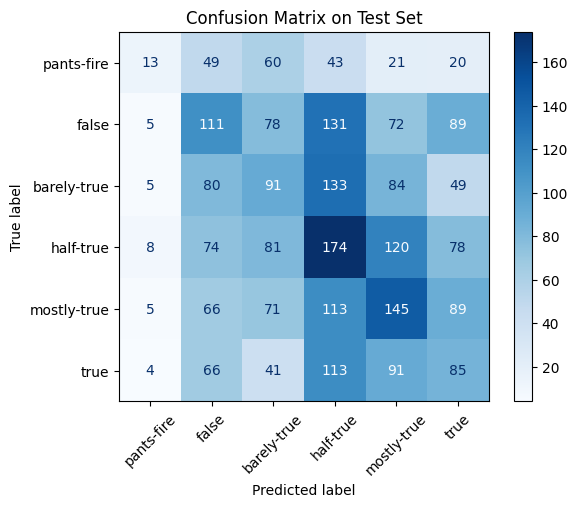

In [ ]:
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
cm = confusion_matrix(all_labels, all_preds)
class_names = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix on Test Set")
plt.show()


The model struggles with correct classification of blatantly false content, and seems to misclassify it as either "barely true" or "false". It also has difficulties with discerning between neighbouring categories. "Barely true" statements are more frequently classified as "half true".

The model has a bias toward the "half true" category, evident from the high values in that column, across all the columns.

In [ ]:
report_dict = classification_report(all_labels, all_preds, target_names=class_names, output_dict=True)
for label in class_names:
    report_dict[label].pop('support', None)
for avg_key in ['macro avg', 'weighted avg']:
    report_dict[avg_key].pop('support', None)

clean_report_df = pd.DataFrame(report_dict).T
print(clean_report_df[['precision', 'recall', 'f1-score']].round(4))


              precision  recall  f1-score
pants-fire       0.3250  0.0631    0.1057
false            0.2489  0.2284    0.2382
barely-true      0.2156  0.2059    0.2106
half-true        0.2461  0.3252    0.2802
mostly-true      0.2720  0.2965    0.2838
true             0.2073  0.2125    0.2099
accuracy         0.2420  0.2420    0.2420
macro avg        0.2525  0.2219    0.2214
weighted avg     0.2466  0.2420    0.2358


Some classes perform significantly worse, like "pants on fire", where the precision is relatively high (0.3250), but the recall is low (0.0631). This means that it misclassifies most of the "pants on fire" statements.



In [ ]:
# Combining the `train_loader` and `val_loader` to evaluate model performance on all the seen data.

combined_training_dataset = ConcatDataset([train_loader.dataset, val_loader.dataset])
combined_loader = DataLoader(combined_training_dataset, batch_size=batch_size, shuffle=False)
accuracy, training_preds, training_labels = bert_valid(model, combined_loader, best_params, loss_fct)
report_dict = classification_report(training_labels, training_preds, target_names=class_names, output_dict=True)
for label in class_names:
    report_dict[label].pop('support', None)
for avg_key in ['macro avg', 'weighted avg']:
    report_dict[avg_key].pop('support', None)

clean_report_df = pd.DataFrame(report_dict).T
print(clean_report_df[['precision', 'recall', 'f1-score']].round(4))

              precision  recall  f1-score
pants-fire       0.8500  0.5516    0.6691
false            0.7777  0.8423    0.8087
barely-true      0.8355  0.8495    0.8424
half-true        0.8844  0.7914    0.8353
mostly-true      0.7003  0.8759    0.7783
true             0.7930  0.7167    0.7529
accuracy         0.7950  0.7950    0.7950
macro avg        0.8068  0.7712    0.7811
weighted avg     0.8031  0.7950    0.7935


## Generating predictions for all the statements in the dataset and storing them in a csv file

In [ ]:
all_ids, all_probs = get_bert_probs(model, test_loader)
probs_array = np.array(all_probs)
df = pd.DataFrame(probs_array, columns=[f'prob_class_{i}' for i in range(probs_array.shape[1])])
df.insert(0, 'id', all_ids)

In [ ]:
x_all = pd.concat([x_train, x_val, x_test]).reset_index(drop=True)
y_all = np.concatenate([y_train, y_val, y_test])
ids_all = np.concatenate([ids_train, ids_val, ids_test])
full_dataset = BERTDataset(x_all, y_all, ids_all, tokenizer, max_length)

full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=False)

ids, probs = get_bert_probs(model, full_loader)

probs_array = np.array(probs)

df_results = pd.DataFrame(probs_array, columns=[f'prob_class_{i}' for i in range(probs_array.shape[1])])
df_results.insert(0, 'id', ids)

In [ ]:
df_results.to_csv('bert_predictions.csv', index=False)